In [1]:
# STANDIN A0
# Load the data, the split and the shared helpers (parts/00_setup.ipynb). Dropped from the hand-in
# notebook, where the setup cells come first.
%run 00_setup.ipynb

Python 3.13.7, scikit-learn 1.6.1, numpy 2.5.3, pandas 3.0.6
Working directory: /home/steven/Desktop/AI-for-Cybersecurity-Final-Mini-Project
Data folder: /home/steven/Desktop/AI-for-Cybersecurity-Final-Mini-Project/UNSW-NB15
score() and score_proba() ready


Rows with an infinite or missing value: 0
Loaded 447,915 flows x 76 features


Raw rows:                      447,915
Exact duplicates removed:      141,742
Conflicting rows removed:        1,068
Clean rows (all are used):     305,105


Dropped 9 constant columns: Bwd PSH Flags, Fwd URG Flags, Bwd URG Flags, URG Flag Count, CWR Flag Count, ECE Flag Count, Fwd Bytes/Bulk Avg, Fwd Packet/Bulk Avg, Fwd Bulk Rate Avg
67 features: 65 continuous, 2 0/1 columns (Fwd PSH Flags, RST Flag Count)
TUNE_IDX: 36,612 training rows for settings searches
Model cache: models/d8137a9708 (20 saved results)
Setup complete: 23 shared names ready in 32 s


In [2]:
# STANDIN B2
# The Part B black box with the settings chosen on validation in B2 (parts/10_baseline_models.ipynb).
# Dropped from the hand-in notebook, where the real B2 cell comes first.
from sklearn.ensemble import HistGradientBoostingClassifier

BOOST_SETTINGS = {"learning_rate": 0.1, "max_leaf_nodes": 31, "random_state": SEED}
BOOST_TAG = f"lr{BOOST_SETTINGS['learning_rate']}_leaves{BOOST_SETTINGS['max_leaf_nodes']}"
def make_boost():
    return HistGradientBoostingClassifier(**BOOST_SETTINGS)

boost = cached(f"B2_boost_{BOOST_TAG}_all", lambda: make_boost().fit(X_train, y_train))   # same cache as B2

<!-- STEP D1 -->
## Part D: global explanation with SHAP

**What SHAP does.** For one flow, SHAP splits the model's output into one contribution per feature:
"`Fwd Seg Size Min` pushed this flow towards *attack* by 2.1, `Bwd Packets/s` pushed it towards *benign*
by 0.4, ...". The contributions add up exactly to the model's output for that flow, starting from a
*base value* (the model's average output). Averaging the size of each feature's contributions over many
flows gives a **global ranking**: which features the model relies on most.

**For gradient boosting the unit is log-odds**, not probability: 0 means 50% attack, +2 about 88%, −2
about 12%. Larger in absolute value means a stronger push. We use `TreeExplainer`, the exact and fast SHAP
method for tree models.

**Which flows.** 1,000 random flows of the **validation** set (seed 42). Part F picks its two features
from this ranking, and choosing anything must not look at the test set.

The feature meanings come from the glossary written by `tools/feature_glossary.py` (`results/tables/T4_feature_glossary.csv`).

In [3]:
# STEP D1
import sys

import matplotlib.pyplot as plt
import shap

sys.path.insert(0, "src")
import xai_tools  # noqa: E402  SHAP/LIME helpers from Lab 3 (src/xai_tools.py)

GLOSSARY = pd.read_csv(TABLES / "T4_feature_glossary.csv", index_col="feature")

EXPLAIN_VAL = X_val.sample(1000, random_state=SEED)          # 1,000 random validation flows
explainer = shap.TreeExplainer(boost)
sv = explainer(EXPLAIN_VAL)
assert sv.values.shape == (1000, len(FEATURES)), sv.values.shape

# Check that the contributions add up: base value + sum of SHAP values = the model's log-odds output.
assert np.allclose(sv.base_values + sv.values.sum(axis=1), boost.decision_function(EXPLAIN_VAL), atol=1e-6)
# The base value is the model's average output in log-odds. It is not the average probability:
# benign flows get very negative log-odds and pull the average far below 0.
print(f"Base value (average model output): {float(np.mean(sv.base_values)):.2f} log-odds")
print(f"The 1,000 flows: {int(y_val.loc[EXPLAIN_VAL.index].sum())} attacks, "
      f"{int((y_val.loc[EXPLAIN_VAL.index] == 0).sum())} benign")

shap_global = (pd.Series(np.abs(sv.values).mean(axis=0), index=FEATURES)
               .sort_values(ascending=False))
top = pd.DataFrame({"mean_abs_shap": shap_global,
                    "share_of_total": shap_global / shap_global.sum()}).head(10)
top["cumulative_share"] = top["share_of_total"].cumsum()
top = top.join(GLOSSARY[["meaning", "direction", "group_proposed"]])
top.index.name = "feature"
top.to_csv(TABLES / "D1_shap_top.csv", float_format="%.4f")
top.style.format({"mean_abs_shap": "{:.3f}", "share_of_total": "{:.1%}", "cumulative_share": "{:.1%}"})

Base value (average model output): -6.73 log-odds
The 1,000 flows: 260 attacks, 740 benign


,mean_abs_shap,share_of_total,cumulative_share,meaning,direction,group_proposed
feature,,,,,,
Fwd Seg Size Min,3.614,42.0%,42.0%,Smallest header size seen in the initiator's packets; depends on the initiator's operating system and TCP options,forward,Free
FWD Init Win Bytes,1.842,21.4%,63.4%,TCP window size in the initiator's first packet: how much data it accepts at once. Set by the initiator's operating system (0 = not TCP or not recorded),forward,Free
Bwd Packets/s,1.113,12.9%,76.4%,How fast the responder sent packets,backward,Fixed
Total Length of Bwd Packet,0.265,3.1%,79.4%,Total payload bytes the responder sent back,backward,Fixed
Packet Length Max,0.183,2.1%,81.6%,"Largest packet payload in the conversation, either direction",both,Fixed
Bwd Packet Length Min,0.170,2.0%,83.5%,Smallest packet payload the responder sent,backward,Fixed
Flow Bytes/s,0.127,1.5%,85.0%,Data rate of the whole conversation (bytes / duration),both,Fixed
Bwd Packet Length Mean,0.095,1.1%,86.1%,Average packet payload the responder sent,backward,Fixed
Packet Length Mean,0.090,1.0%,87.2%,"Average packet payload, both directions together",both,Fixed


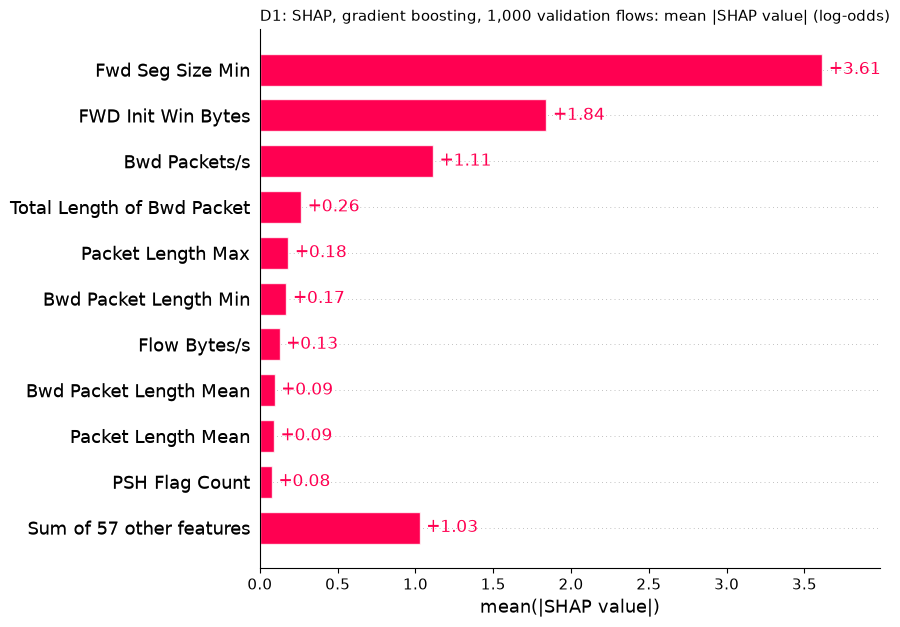

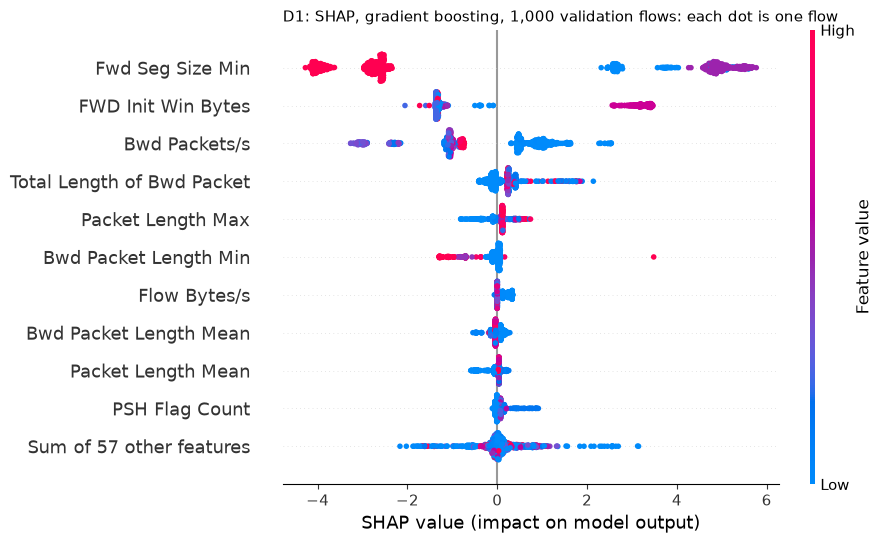

In [4]:
# STEP D1
# Bar plot: average size of each feature's contribution. Beeswarm: one dot per flow, coloured by the
# feature's value (red = high, blue = low); dots to the right push towards "attack".
shap.plots.bar(sv, max_display=11, show=False)
plt.title("D1: SHAP, gradient boosting, 1,000 validation flows: mean |SHAP value| (log-odds)",
          loc="left", fontsize=11)
plt.savefig(FIGURES / "D1_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

shap.plots.beeswarm(sv, max_display=11, show=False)
plt.title("D1: SHAP, gradient boosting, 1,000 validation flows: each dot is one flow", loc="left",
          fontsize=11)
plt.savefig(FIGURES / "D1_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# STEP D1
# The two top features in the training data: how many flows have each value, and how many of them are
# attacks. (Used in the interpretation below.)
rows = []
for feature, values in [("Fwd Seg Size Min", [8, 20, 32]), ("FWD Init Win Bytes", [0, 16383, 5792])]:
    for value in values:
        has = (X_train[feature] == value).to_numpy()
        rows.append({"feature": feature, "value": value, "training_flows": int(has.sum()),
                     "attack_share": float(y_train.to_numpy()[has].mean())})
fingerprint_table = pd.DataFrame(rows)
fingerprint_table.to_csv(TABLES / "D1_fingerprint_values.csv", index=False, float_format="%.4f")
attacks_train = (y_train == 1).to_numpy()
with_window = int((attacks_train & (X_train["FWD Init Win Bytes"] == 16383).to_numpy()).sum())
print(f"Training attacks with FWD Init Win Bytes = 16,383: {with_window:,} of {int(attacks_train.sum()):,} "
      f"({with_window / attacks_train.sum():.1%})")
fingerprint_table.style.format({"training_flows": "{:,}", "attack_share": "{:.1%}"})

Training attacks with FWD Init Win Bytes = 16,383: 45,850 of 48,154 (95.2%)


,feature,value,training_flows,attack_share
0,Fwd Seg Size Min,8,"25,518",9.0%
1,Fwd Seg Size Min,20,"51,290",89.4%
2,Fwd Seg Size Min,32,"106,079",0.0%
3,FWD Init Win Bytes,0,"25,518",9.0%
4,FWD Init Win Bytes,16383,"50,962",90.0%
5,FWD Init Win Bytes,5792,"87,387",0.0%


<!-- STEP D1 -->
### What the global SHAP picture shows

**Three features carry three quarters of the model's reasoning.** `Fwd Seg Size Min` (42% of the total
SHAP weight), `FWD Init Win Bytes` (21%) and `Bwd Packets/s` (13%) together account for 76%; the other
64 features share the rest. (The base value, the model's average output, is −6.7 log-odds; that every
contribution adds up exactly to the model's output is checked in the code.)

**The top two describe the attacker's machine, not the attack.** Both are TCP settings that the operating
system of the initiating computer chooses when it opens a connection. In the training data (code cell above):

| Value | Training flows | Share that are attacks |
|---|---:|---:|
| `Fwd Seg Size Min` = 20 bytes | 51,290 | 89% |
| `Fwd Seg Size Min` = 32 bytes | 106,079 | 0% |
| `FWD Init Win Bytes` = 16,383 | 50,962 | 90% |
| `FWD Init Win Bytes` = 5,792 | 87,387 | 0% |

95% of all training attacks (45,850 of 48,154) open their connection with a window of exactly 16,383 bytes.
In the beeswarm this shows as two well-separated clouds per feature: one value pushes strongly towards
"attack", the other strongly towards "benign". In UNSW-NB15 all attacks were generated by a few attacker
machines with their own TCP settings, while the normal traffic came from other machines. The model has
learned to **recognise those machines**: a *shortcut* that works on this dataset but says nothing about
what an attack does.

**Do the features make sense to a security person? Only partly.**
- `Fwd Seg Size Min` and `FWD Init Win Bytes`: no, not as evidence of an attack. They are a fingerprint of
  the machine. An attacker using another operating system, or changing two TCP settings on their own
  machine, would no longer look like this, and a normal computer that happens to share these settings
  would look like an attacker. A security person would use them to recognise *known* machines, not
  attacks in general.
- `Bwd Packets/s` (how fast the other side replies), `Total Length of Bwd Packet`, `Packet Length Max`,
  `Bwd Packet Length Min` and `Flow Bytes/s`: yes. They describe the conversation itself: scans and
  floods get few or no replies from the victim, exploits and fuzzing send unusual packet sizes. These are
  the kind of evidence an analyst would look at.

This shortcut is the most important finding of Part D. It explains why the models in Part B are so
accurate, it is what an attacker could fake most cheaply (step E4), and it reappears in Parts F and G.
The optional extra X6 tests how well the model does without the TCP-settings features.

<!-- STEP D2 -->
## Part D: three flows to explain

The brief asks for three local explanations: **a confident correct detection, a confident correct
negative, and a mistake**. We pick them from the **test** set with the black box's attack probability:

- **detection**: the true attack with the highest attack probability;
- **negative**: the true benign flow with the lowest attack probability;
- **mistake**: the wrongly classified flow the model was most sure about (probability furthest from 0.5).
  It can be a false alarm (benign called attack) or a missed attack.

When several flows tie (many get a probability of practically 1 or 0), the first one in test-set order is
taken, so the choice is reproducible. Explaining test flows is allowed: it changes no model or setting.
The positions are stored in `CASES` and used by D3–D6 and by Part F.

In [6]:
# STEP D2
p_test = boost.predict_proba(X_test)[:, 1]
pred_test = (p_test >= 0.5).astype(int)
y_true = y_test.to_numpy()

caught = np.flatnonzero((y_true == 1) & (pred_test == 1))
cleared = np.flatnonzero((y_true == 0) & (pred_test == 0))
wrong = np.flatnonzero(pred_test != y_true)

# argmax / argmin return the first position on a tie (test-set order), so the choice is reproducible.
CASES = {"detection": int(caught[np.argmax(p_test[caught])]),
         "negative": int(cleared[np.argmin(p_test[cleared])]),
         "mistake": int(wrong[np.argmax(np.abs(p_test[wrong] - 0.5))])}

print(f"Test flows: {len(caught):,} correct detections, {len(cleared):,} correct negatives, "
      f"{len(wrong):,} mistakes ({int((y_true[wrong] == 0).sum()):,} false alarms, "
      f"{int((y_true[wrong] == 1).sum()):,} missed attacks)")
print(f"Ties: {int((p_test[caught] == p_test[caught].max()).sum())} detections share the highest "
      f"probability, {int((p_test[cleared] == p_test[cleared].min()).sum())} negatives the lowest")

TOP3 = list(shap_global.index[:3])
cases = pd.DataFrame([{
    "case": name, "test_position": pos, "attack_type": type_test.iloc[pos],
    "true_label": "attack" if y_true[pos] == 1 else "benign",
    "called": "attack" if pred_test[pos] == 1 else "benign",
    "attack_probability": p_test[pos],
    **{f: X_test.iloc[pos][f] for f in TOP3},
} for name, pos in CASES.items()]).set_index("case")
cases.to_csv(TABLES / "D2_cases.csv", float_format="%.6g")
cases

Test flows: 15,928 correct detections, 43,728 correct negatives, 1,365 mistakes (1,241 false alarms, 124 missed attacks)
Ties: 1 detections share the highest probability, 1 negatives the lowest


,test_position,attack_type,true_label,called,attack_probability,Fwd Seg Size Min,FWD Init Win Bytes,Bwd Packets/s
case,,,,,,,,
detection,50065,Exploits,attack,attack,9.995756e-01,20.0,16383.0,22.675749
negative,47114,Benign,benign,benign,2.061596e-07,8.0,0.0,2006.018054
mistake,10048,Benign,benign,attack,9.989081e-01,20.0,16383.0,23.214244


In [7]:
# STEP D2
# How much of the model's behaviour on the test set follows the attacker fingerprint
# (Fwd Seg Size Min = 20 and FWD Init Win Bytes = 16,383, see D1)?
fingerprint = ((X_test["Fwd Seg Size Min"] == 20) & (X_test["FWD Init Win Bytes"] == 16383)).to_numpy()
false_alarm = (y_true == 0) & (pred_test == 1)
missed = (y_true == 1) & (pred_test == 0)
fp_check = pd.DataFrame({
    "flows": [int((fingerprint & (y_true == 1)).sum()), int((fingerprint & (y_true == 0)).sum()),
              int((~fingerprint & (y_true == 1)).sum()), int((~fingerprint & (y_true == 0)).sum())],
    "called attack": [float(pred_test[fingerprint & (y_true == 1)].mean()),
                      float(pred_test[fingerprint & (y_true == 0)].mean()),
                      float(pred_test[~fingerprint & (y_true == 1)].mean()),
                      float(pred_test[~fingerprint & (y_true == 0)].mean())],
}, index=pd.MultiIndex.from_tuples([("fingerprint", "attack"), ("fingerprint", "benign"),
                                    ("no fingerprint", "attack"), ("no fingerprint", "benign")],
                                   names=["test flows with", "true label"]))
fp_check.to_csv(TABLES / "D2_fingerprint_check.csv", float_format="%.4f")
print(f"False alarms with the fingerprint: {int((false_alarm & fingerprint).sum()):,} of {int(false_alarm.sum()):,}")
print(f"Missed attacks without the fingerprint: {int((missed & ~fingerprint).sum()):,} of {int(missed.sum()):,}")
fp_check.style.format({"flows": "{:,}", "called attack": "{:.1%}"})

False alarms with the fingerprint: 1,197 of 1,241
Missed attacks without the fingerprint: 4 of 124


<!-- STEP D2 -->
### The three flows and what they already show

| Case | Test position | Type | Called | Attack probability | `Fwd Seg Size Min` | `FWD Init Win Bytes` | `Bwd Packets/s` |
|---|---:|---|---|---:|---:|---:|---:|
| detection | 50,065 | Exploits | attack | 0.9996 | 20 | 16,383 | 22.7 |
| negative | 47,114 | Benign | benign | 0.0000002 | 8 | 0 | 2,006 |
| mistake | 10,048 | **Benign** | **attack** | 0.9989 | 20 | 16,383 | 23.2 |

**The mistake is a false alarm that looks exactly like the detection** on the three most important
features: the same attacker fingerprint (`Fwd Seg Size Min` = 20, `FWD Init Win Bytes` = 16,383) and
almost the same reply rate. The model is 99.9% sure it is an attack. The negative has a completely
different profile (no TCP window at all, which usually means the flow is not a TCP connection, and a fast
reply rate). D3 explains all three with SHAP and LIME.

**The fingerprint explains almost all false alarms** (second table above):
- **1,197 of the 1,241 false alarms (96%)** are benign flows with the attacker fingerprint. Of the 1,731
  benign test flows that carry it, 69% are called attacks; of the 43,238 benign flows without it, only
  0.1%. These benign flows probably come from the same kind of machines as the attacks (in the full
  recording, 1.6% of benign flows come from the attacker addresses), so the model cannot tell them apart.
- **The model is not *only* the fingerprint.** The 749 attacks without it are still caught 99.5% of the
  time, through the behaviour features (reply rate, packet sizes). And 120 of the 124 missed attacks *do*
  carry the fingerprint: among fingerprint flows, the behaviour features decide, and that is where both
  kinds of mistake happen.

So the fingerprint sorts flows into "attacker-like machine" or not, and within the attacker-like group the
behaviour features do the fine work. A benign computer that shares the attacker's TCP settings is very
likely to be flagged.

<!-- STEP D3 -->
## Part D: local explanations of the three flows, with SHAP and with LIME

Each of the three flows from D2 is explained twice:

- **SHAP waterfall**: starts at the base value (the model's average output) and adds each feature's
  contribution until it reaches this flow's output. Bars to the right push towards *attack*, to the left
  towards *benign*. Units are log-odds (D1). SHAP for trees is exact: it describes the model itself.
- **LIME**: makes 5,000 slightly changed copies of the flow, asks the model about each, and fits a
  simple straight-line model to those answers. Its explanation is a list of conditions such as
  "`Fwd Seg Size Min` ≤ 20" with a weight: positive pushes towards attack. Units are probability. LIME
  turns each continuous feature into ranges (quartiles of the training data) before fitting.
  Its **fit score** (R², 0 to 1) says how well the straight line matches the model around this flow;
  below 0.5, LIME's explanation should not be trusted much.

Then we compare the **top 3 features** of each method for each flow.

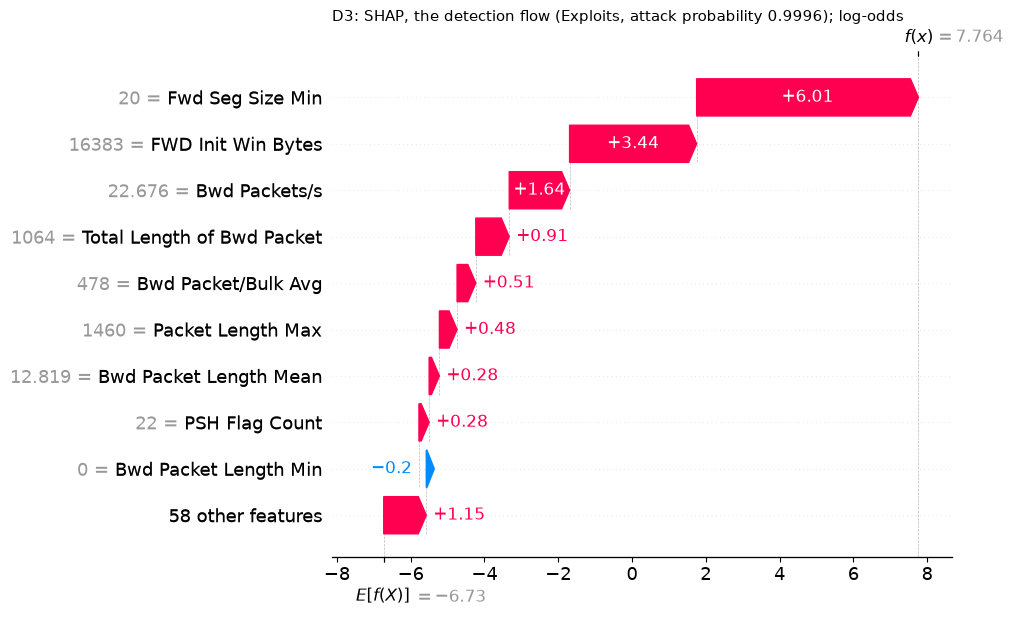

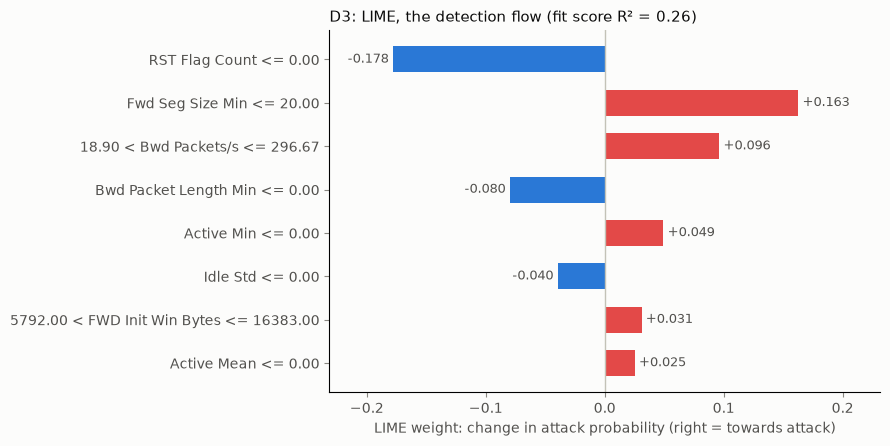

detection: LIME conditions (weight in attack probability):
   -0.178  RST Flag Count <= 0.00
   +0.163  Fwd Seg Size Min <= 20.00
   +0.096  18.90 < Bwd Packets/s <= 296.67
   -0.080  Bwd Packet Length Min <= 0.00
   +0.049  Active Min <= 0.00
   -0.040  Idle Std <= 0.00
   +0.031  5792.00 < FWD Init Win Bytes <= 16383.00
   +0.025  Active Mean <= 0.00


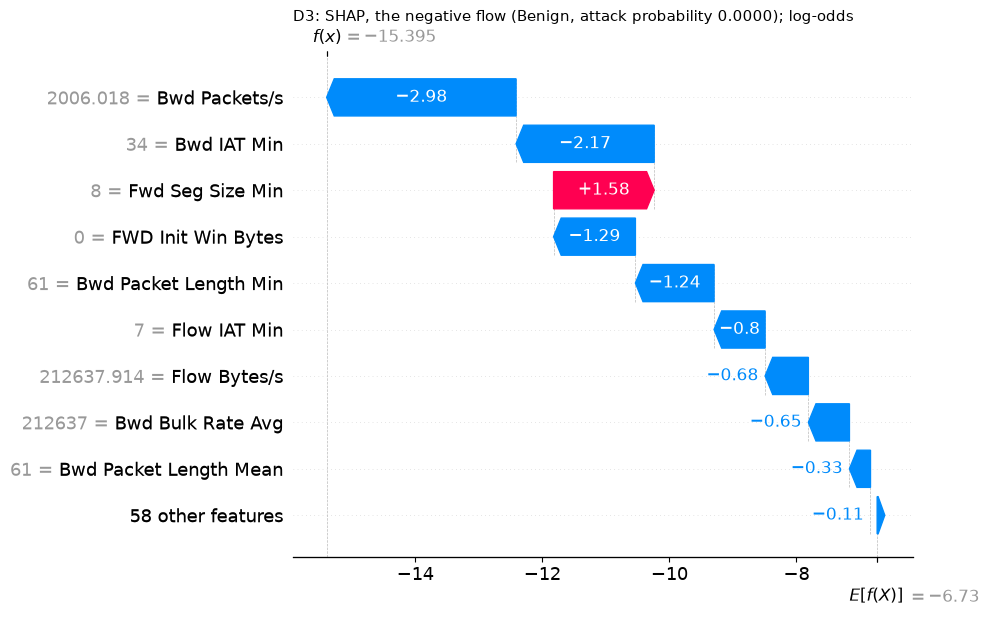

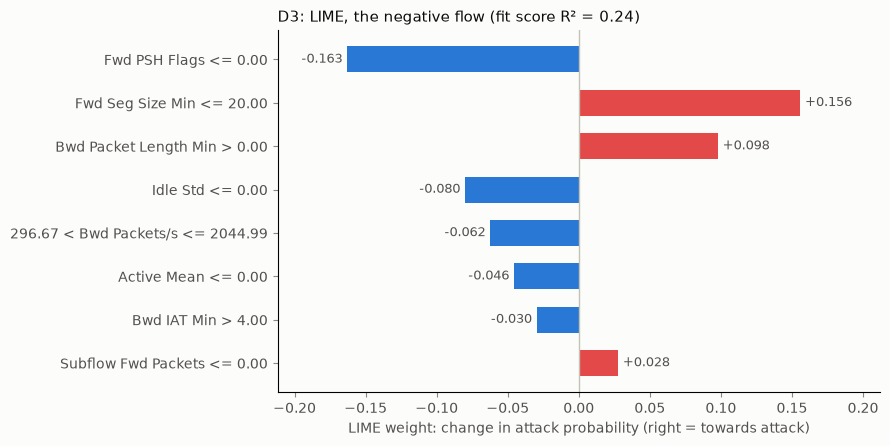

negative: LIME conditions (weight in attack probability):
   -0.163  Fwd PSH Flags <= 0.00
   +0.156  Fwd Seg Size Min <= 20.00
   +0.098  Bwd Packet Length Min > 0.00
   -0.080  Idle Std <= 0.00
   -0.062  296.67 < Bwd Packets/s <= 2044.99
   -0.046  Active Mean <= 0.00
   -0.030  Bwd IAT Min > 4.00
   +0.028  Subflow Fwd Packets <= 0.00


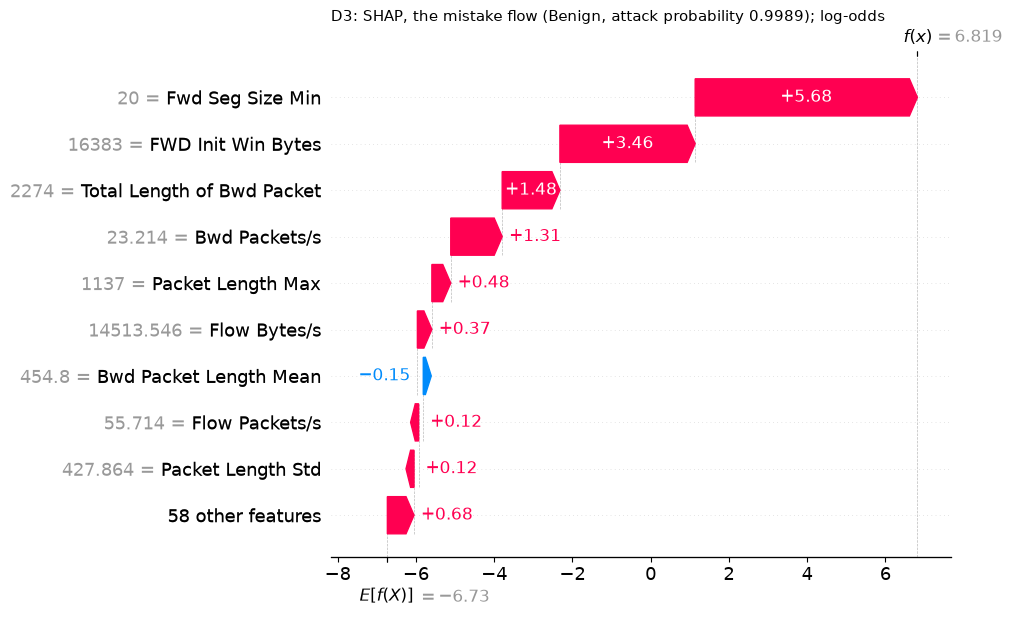

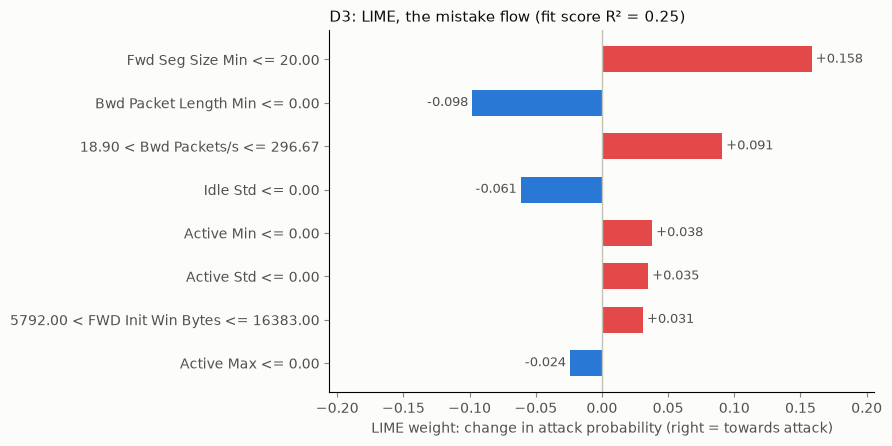

mistake: LIME conditions (weight in attack probability):
   +0.158  Fwd Seg Size Min <= 20.00
   -0.098  Bwd Packet Length Min <= 0.00
   +0.091  18.90 < Bwd Packets/s <= 296.67
   -0.061  Idle Std <= 0.00
   +0.038  Active Min <= 0.00
   +0.035  Active Std <= 0.00
   +0.031  5792.00 < FWD Init Win Bytes <= 16383.00
   -0.024  Active Max <= 0.00


,attack_type,attack_probability,SHAP_top3,LIME_top3,shared_in_top3,LIME_fit_score,LIME_local_prediction
case,,,,,,,
detection,Exploits,9.995756e-01,"Fwd Seg Size Min, FWD Init Win Bytes, Bwd Pack...","RST Flag Count, Fwd Seg Size Min, Bwd Packets/s",2,0.259469,0.246893
negative,Benign,2.061596e-07,"Bwd Packets/s, Bwd IAT Min, Fwd Seg Size Min","Fwd PSH Flags, Fwd Seg Size Min, Bwd Packet Le...",1,0.238867,0.172661
mistake,Benign,9.989081e-01,"Fwd Seg Size Min, FWD Init Win Bytes, Total Le...","Fwd Seg Size Min, Bwd Packet Length Min, Bwd P...",1,0.253149,0.236865


In [8]:
# STEP D3
from lime.lime_tabular import LimeTabularExplainer


def predict_fn(a):
    """The black box for LIME and the xai_tools helpers: they pass plain numbers, the model wants a table."""
    return boost.predict_proba(pd.DataFrame(a, columns=FEATURES))


def d3_lime():
    """LIME for the three flows, one explainer with seed 42, in the order of CASES (as computed in D3)."""
    lime_explainer = LimeTabularExplainer(X_train.to_numpy(), feature_names=FEATURES,
                                          class_names=["benign", "attack"], discretize_continuous=True,
                                          random_state=SEED)
    return {name: xai_tools.lime_explain(lime_explainer, predict_fn, X_test.iloc[pos].to_numpy(),
                                         num_features=8, num_samples=5000)[1]
            for name, pos in CASES.items()}


# Building a LIME explainer on 183,063 rows takes about 40 s, so the results are cached.
lime_d3 = cached("D3_lime", d3_lime)

# Same colours as SHAP's plots: red = pushes towards attack, blue = towards benign (a validated
# diverging pair; LIME's own red/green plot is hard to read for colour-blind readers).
TO_ATTACK, TO_BENIGN = "#e34948", "#2a78d6"


def plot_lime(summary, title, path):
    """Horizontal bars of LIME's conditions and weights, the largest at the top, values written out."""
    conditions = summary["conditions"][::-1]
    labels = [c for c, _ in conditions]
    weights = np.array([w for _, w in conditions])
    fig, ax = plt.subplots(figsize=(9, 0.42 * len(labels) + 1.2), facecolor="#fcfcfb")
    ax.set_facecolor("#fcfcfb")
    ax.barh(labels, weights, color=np.where(weights > 0, TO_ATTACK, TO_BENIGN), height=0.6)
    ax.axvline(0, color="#c3c2b7", linewidth=1)
    span = np.abs(weights).max()
    for i, w in enumerate(weights):
        ax.text(w + (0.02 if w > 0 else -0.02) * span, i, f"{w:+.3f}", va="center",
                ha="left" if w > 0 else "right", color="#52514e", fontsize=9)
    ax.set_xlim(-1.3 * span, 1.3 * span)
    ax.set_xlabel("LIME weight: change in attack probability (right = towards attack)", color="#52514e")
    ax.set_title(title, loc="left", fontsize=11, color="#0b0b0b")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.tick_params(colors="#898781", labelcolor="#52514e")
    fig.tight_layout()
    fig.savefig(path, dpi=150, facecolor="#fcfcfb")
    plt.show()

case_shap, case_lime, rows = {}, {}, []
for name, pos in CASES.items():
    x = X_test.iloc[[pos]]
    one = explainer(x)[0]                                   # SHAP for this flow
    case_shap[name] = pd.Series(one.values, index=FEATURES)

    shap.plots.waterfall(one, max_display=10, show=False)
    plt.title(f"D3: SHAP, the {name} flow ({type_test.iloc[pos]}, attack probability "
              f"{p_test[pos]:.4f}); log-odds", loc="left", fontsize=11)
    plt.savefig(FIGURES / f"D3_shap_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

    summary = lime_d3[name]
    case_lime[name] = summary
    plot_lime(summary, f"D3: LIME, the {name} flow (fit score R² = {summary['score']:.2f})",
              FIGURES / f"D3_lime_{name}.png")

    shap_top3 = list(case_shap[name].abs().sort_values(ascending=False).index[:3])
    lime_top3 = list(summary["weights"].abs().sort_values(ascending=False).index[:3])
    rows.append({"case": name, "attack_type": type_test.iloc[pos], "attack_probability": p_test[pos],
                 "SHAP_top3": ", ".join(shap_top3), "LIME_top3": ", ".join(lime_top3),
                 "shared_in_top3": xai_tools.topk_overlap(case_shap[name], summary["weights"], k=3),
                 "LIME_fit_score": summary["score"], "LIME_local_prediction": summary["local_pred"]})
    print(f"{name}: LIME conditions (weight in attack probability):")
    for condition, weight in summary["conditions"]:
        print(f"   {weight:+.3f}  {condition}")

top3 = pd.DataFrame(rows).set_index("case")
top3.to_csv(TABLES / "D3_top3.csv", float_format="%.4f")
top3

<!-- STEP D3 -->
### What the local explanations show

| Case | SHAP top 3 | LIME top 3 | Shared | LIME fit (R²) |
|---|---|---|---:|---:|
| detection (Exploits, p = 0.9996) | `Fwd Seg Size Min`, `FWD Init Win Bytes`, `Bwd Packets/s` | `RST Flag Count`, `Fwd Seg Size Min`, `Bwd Packets/s` | 2 | 0.26 |
| negative (Benign, p ≈ 0) | `Bwd Packets/s`, `Bwd IAT Min`, `Fwd Seg Size Min` | `Fwd PSH Flags`, `Fwd Seg Size Min`, `Bwd Packet Length Min` | 1 | 0.24 |
| mistake (Benign, p = 0.9989) | `Fwd Seg Size Min`, `FWD Init Win Bytes`, `Total Length of Bwd Packet` | `Fwd Seg Size Min`, `Bwd Packet Length Min`, `Bwd Packets/s` | 1 | 0.25 |

**SHAP tells a clear story.**
- **Detection and mistake are explained the same way.** For the false alarm, `Fwd Seg Size Min` = 20
  adds +5.7 log-odds and `FWD Init Win Bytes` = 16,383 adds +3.5: the attacker fingerprint alone takes
  the flow from far below to far above the decision line. The behaviour features add a little more
  (`Total Length of Bwd Packet` +1.5, `Bwd Packets/s` +1.3). **The model flags this benign flow because
  it comes from an attacker-like machine**, which is the shortcut from D1 and D2 seen on a single flow.
- **The negative is cleared by its behaviour.** A fast reply rate (`Bwd Packets/s` = 2,006, −3.0), quick
  replies (`Bwd IAT Min`, −2.2) and replies of 61 bytes (`Bwd Packet Length Min`, −1.2) push it far
  towards benign. `Fwd Seg Size Min` = 8 actually pushes *towards* attack (+1.6), but is outweighed.

**LIME agrees only partly, and its explanations are unreliable here.**
- **The fit scores are only 0.24–0.26.** LIME's straight line explains about a quarter of how the model
  behaves around these flows. Its local prediction for the detection is 0.25, while the model says 0.9996.
  By the rule from the explanation above (below 0.5: do not trust it much), none of the three LIME
  explanations should be trusted on its own.
- **LIME's ranges hide the difference the model uses.** For the negative flow, LIME's second-strongest
  condition is "`Fwd Seg Size Min` ≤ 20", pushing towards attack (+0.156). But this flow has the value 8.
  LIME splits each feature into quartile ranges of the training data, and 8 and 20 fall into the same
  range, although for the model they mean opposite things (20: 89% attacks in training; 8: 9%). The
  condition is true for the flow, but it describes the range, not the value.
- **LIME puts 0/1 flags near the top** (`RST Flag Count` for the detection, `Fwd PSH Flags` for the
  negative), which barely move the model in SHAP. Changing a flag from 0 to 1 is a big jump in LIME's
  random copies, so they get large weights in its line.

Both methods name `Fwd Seg Size Min` among the top features for all three flows. Beyond that they agree
on only one or two of three. Step D5 tests how stable LIME is, and step D6 checks these reasons for the
disagreement one by one.

<!-- STEP D4 -->
## Part D: fidelity, the deletion test

**Question.** Do the features SHAP calls most important really drive the model's decision? If they do,
removing them should change the prediction much more than removing the same number of features at
random.

**How.** We take 500 test flows that the model calls attacks (random, seed 42). For each flow we
replace its *k* most important features (by the size of its own SHAP values) with the **training
median** of each feature, an "ordinary" value, and measure how much the attack probability drops. We do
the same with *k* **random** features as the baseline, for k = 1, 3, 5 and 10. We also count how often
the decision flips from attack to benign.

A clearly bigger drop for SHAP than for random means the explanation is **faithful** to the model.
(`xai_tools.deletion_test` from Lab 3 does the replacing and measuring.)

In [9]:
# STEP D4
attack_called = np.flatnonzero(pred_test == 1)
rng = np.random.default_rng(SEED)
deletion_pos = np.sort(rng.choice(attack_called, size=500, replace=False))
X_del = X_test.iloc[deletion_pos]
shap_del = explainer(X_del).values                      # each flow's own SHAP values

deletion = xai_tools.deletion_test(predict_fn, X_del.to_numpy(), {"SHAP": shap_del},
                                   TRAIN_MEDIAN[FEATURES].to_numpy(), ks=(1, 3, 5, 10), seed=SEED)
deletion["method"] = deletion["method"].replace({"random": "random features"})
deletion.to_csv(TABLES / "D4_deletion.csv", index=False, float_format="%.4f")
print(f"500 flows called attack: {int(y_test.iloc[deletion_pos].sum())} true attacks, "
      f"{int((y_test.iloc[deletion_pos] == 0).sum())} false alarms; "
      f"mean attack probability before {p_test[deletion_pos].mean():.3f}")

# Which features does SHAP name first, and what is their training median?
first = pd.Series(np.array(FEATURES)[np.abs(shap_del).argmax(axis=1)]).value_counts()
print("\nFeature replaced at k = 1 (the flow's most important), with its training median:")
print(pd.DataFrame({"flows": first, "training_median": TRAIN_MEDIAN[first.index]}).to_string())
deletion.round(4)

500 flows called attack: 469 true attacks, 31 false alarms; mean attack probability before 0.921

Feature replaced at k = 1 (the flow's most important), with its training median:
                  flows  training_median
Fwd Seg Size Min    500             32.0


,method,k,mean_drop,std_drop,share_flipped
0,SHAP,1,0.9189,0.0927,1.000
1,SHAP,3,0.9209,0.0933,1.000
2,SHAP,5,0.9209,0.0933,1.000
3,SHAP,10,0.9209,0.0933,1.000
4,random features,1,0.0202,0.1307,0.028
5,random features,3,0.0720,0.2377,0.088
6,random features,5,0.1166,0.2910,0.138
7,random features,10,0.2244,0.3784,0.254


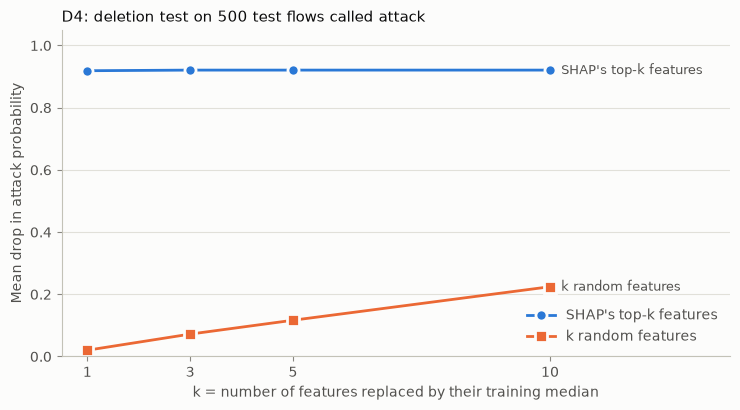

In [10]:
# STEP D4
fig, ax = plt.subplots(figsize=(7.5, 4.2), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
styles = {"SHAP": ("#2a78d6", "o", "SHAP's top-k features"),
          "random features": ("#eb6834", "s", "k random features")}
for method, (colour, marker, label) in styles.items():
    part = deletion[deletion["method"] == method]
    ax.plot(part["k"], part["mean_drop"], color=colour, marker=marker, linewidth=2, markersize=8,
            markeredgecolor="#fcfcfb", markeredgewidth=2, label=label)
    ax.annotate(label, xy=(part["k"].iloc[-1], part["mean_drop"].iloc[-1]), xytext=(8, 0),
                textcoords="offset points", va="center", color="#52514e", fontsize=9)
ax.set_xticks([1, 3, 5, 10])
ax.set_xlim(0.5, 13.5)
ax.set_ylim(0, 1.05)
ax.set_xlabel("k = number of features replaced by their training median", color="#52514e")
ax.set_ylabel("Mean drop in attack probability", color="#52514e")
ax.set_title("D4: deletion test on 500 test flows called attack", loc="left", fontsize=11, color="#0b0b0b")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#c3c2b7")
ax.tick_params(colors="#898781", labelcolor="#52514e")
ax.legend(loc="lower right", frameon=False, labelcolor="#52514e")
fig.tight_layout()
fig.savefig(FIGURES / "D4_deletion.png", dpi=150, facecolor="#fcfcfb")
plt.show()

<!-- STEP D4 -->
### What the deletion test shows

| Features replaced (k) | SHAP's top-k: mean drop | flipped to benign | k random: mean drop | flipped to benign |
|---:|---:|---:|---:|---:|
| 1 | 0.919 | 100% | 0.020 | 2.8% |
| 3 | 0.921 | 100% | 0.072 | 8.8% |
| 5 | 0.921 | 100% | 0.117 | 13.8% |
| 10 | 0.921 | 100% | 0.224 | 25.4% |

**SHAP is faithful.** Replacing only the single feature SHAP ranks first flips every one of the 500
decisions from attack to benign, and the attack probability falls from 0.92 on average to almost 0.
Replacing ten random features changes a quarter of the decisions at most. The features SHAP points to
really are the ones the model's decisions depend on.

**But the result is also a warning about the model.** For all 500 flows the top feature is the same one,
`Fwd Seg Size Min`, and its training median is 32, the value of the *benign* machines (D1: 0% attacks in
training). So "replacing it with an ordinary value" means giving the flow a normal machine's TCP setting,
and **that single change is enough to make every attack look benign**. The other 66 features, including
all the behaviour features, cannot hold the decision on their own once the fingerprint is gone. This is
the shortcut from D1 seen as cause and effect, and it matters for Part E: an attacker who changes one TCP
setting on their own machine would likely evade this detector.

**Why the SHAP line is flat after k = 1.** After the first replacement the attack probability is already
near 0, so replacing more features has nothing left to change. The random line rises with k partly
because a random choice of 10 out of 67 features often includes `Fwd Seg Size Min` itself (in about 15%
of draws), which then flips the decision.

**Limits of this test.**
- The median is not a neutral value for this feature: it is the benign machines' setting. With a
  different "ordinary" value the drop could be smaller. The test shows that SHAP points at the decisive
  feature, not that the median is a fair stand-in.
- A flow with a changed header field but everything else unchanged may be a combination that never occurs
  in real traffic. The model has to answer anyway, so the test measures the model's reaction to edited
  flows, not to real ones.
- With one feature deciding everything, the test says little about how faithful SHAP is for the *other*
  features. The optional extra X6 (the model without the TCP-settings features) is the way to check that.

<!-- STEP D5 -->
## Part D: stability of LIME

**Question.** LIME uses randomness: it explains a flow by asking the model about 5,000 randomly changed
copies of it. If a second run with another random seed gives different top features, an analyst cannot
trust either run.

**How.** For each of the three flows from D2, LIME is run **10 times with seeds 0 to 9** (same settings
as in D3: 8 features, 5,000 samples). For each flow we report:

- **same top 3**: the share of the 10 runs whose top-3 features (by the size of their weight) are exactly
  the most common top-3 set;
- **mean overlap (Jaccard)**: for every pair of runs, the share of top-3 features they have in common,
  averaged (1 = always the same three features);
- the features that are in the top 3 of **all** 10 runs, and the fit score of each run.

For comparison, SHAP is run twice on the same flow: `TreeExplainer` is exact, so it should give identical
values every time.

In [11]:
# STEP D5
import itertools

from sklearn.utils import check_random_state


def lime_reseeded(lime, seed):
    """The same explainer, reset to a new seed: gives exactly what a new explainer with that seed gives
    (checked: identical results), without the 40 s it takes to build one on all training rows."""
    rs = check_random_state(seed)
    lime.random_state = rs
    if getattr(lime, "discretizer", None) is not None:
        lime.discretizer.random_state = rs
    return lime


def lime_seed_runs(seeds, num_samples):
    """LIME on each of the three flows for each seed: {(case, seed): summary}."""
    lime = xai_tools.make_lime(X_train.to_numpy(), FEATURES, seed=0)
    return {(name, seed): xai_tools.lime_explain(lime_reseeded(lime, seed), predict_fn,
                                                 X_test.iloc[pos].to_numpy(), num_features=8,
                                                 num_samples=num_samples)[1]
            for name, pos in CASES.items() for seed in seeds}


d5_runs = cached("D5_lime_seeds", lambda: lime_seed_runs(range(10), 5000))

run_rows, summary_rows = [], []
for name, pos in CASES.items():
    tops, scores = [], []
    for seed in range(10):
        summary = d5_runs[(name, seed)]
        top3 = frozenset(summary["weights"].abs().sort_values(ascending=False).index[:3])
        tops.append(top3)
        scores.append(summary["score"])
        run_rows.append({"case": name, "seed": seed, "top3": ", ".join(sorted(top3)),
                         "fit_score": summary["score"]})
    most_common = max(set(tops), key=tops.count)
    jaccard = np.mean([len(a & b) / len(a | b) for a, b in itertools.combinations(tops, 2)])
    summary_rows.append({"case": name, "same_top3_as_most_common": tops.count(most_common) / len(tops),
                         "distinct_top3_sets": len(set(tops)), "mean_jaccard_top3": jaccard,
                         "most_common_top3": ", ".join(sorted(most_common)),
                         "in_top3_of_all_runs": ", ".join(sorted(frozenset.intersection(*tops))),
                         "fit_score_mean": np.mean(scores), "fit_score_min": np.min(scores),
                         "fit_score_max": np.max(scores)})

lime_runs = pd.DataFrame(run_rows)
lime_stability = pd.DataFrame(summary_rows).set_index("case")
lime_runs.to_csv(TABLES / "D5_lime_runs.csv", index=False, float_format="%.4f")
lime_stability.to_csv(TABLES / "D5_lime_stability.csv", float_format="%.4f")

# SHAP for comparison: two runs on the same flow.
shap_same = all(np.array_equal(explainer(X_test.iloc[[pos]]).values, explainer(X_test.iloc[[pos]]).values)
                for pos in CASES.values())
print(f"SHAP: two runs give identical values for all three flows: {shap_same}")
print("\nLIME top 3 per seed:")
print(lime_runs.pivot(index="seed", columns="case", values="top3").to_string())
lime_stability

SHAP: two runs give identical values for all three flows: True

LIME top 3 per seed:
case                                               detection                                                 mistake                                                negative
seed                                                                                                                                                                        
0     Bwd Packet Length Min, Bwd Packets/s, Fwd Seg Size Min  Bwd Packet Length Min, Bwd Packets/s, Fwd Seg Size Min  Bwd Packet Length Min, Bwd Packets/s, Fwd Seg Size Min
1     Bwd Packet Length Min, Bwd Packets/s, Fwd Seg Size Min  Bwd Packet Length Min, Bwd Packets/s, Fwd Seg Size Min  Bwd Packet Length Min, Bwd Packets/s, Fwd Seg Size Min
2     Bwd Packet Length Min, Bwd Packets/s, Fwd Seg Size Min  Bwd Packet Length Min, Bwd Packets/s, Fwd Seg Size Min       Bwd Packet Length Min, Fwd Seg Size Min, Idle Std
3     Bwd Packet Length Min, Bwd Packets/s, Fwd Se

,same_top3_as_most_common,distinct_top3_sets,mean_jaccard_top3,most_common_top3,in_top3_of_all_runs,fit_score_mean,fit_score_min,fit_score_max
case,,,,,,,,
detection,0.8,3,0.804444,"Bwd Packet Length Min, Bwd Packets/s, Fwd Seg ...",Fwd Seg Size Min,0.254037,0.241669,0.264720
negative,0.5,5,0.622222,"Bwd Packet Length Min, Bwd Packets/s, Fwd Seg ...","Bwd Packet Length Min, Fwd Seg Size Min",0.227259,0.217236,0.237370
mistake,0.8,3,0.804444,"Bwd Packet Length Min, Bwd Packets/s, Fwd Seg ...",Fwd Seg Size Min,0.255457,0.245596,0.267731


<!-- STEP D5 -->
### What the stability test shows

| Flow | Runs with the most common top 3 | Different top-3 sets | Mean overlap (Jaccard) | In the top 3 of all 10 runs | Fit score (R²) |
|---|---:|---:|---:|---|---|
| detection | 8 of 10 | 3 | 0.80 | `Fwd Seg Size Min` | 0.24 to 0.26 |
| negative | 5 of 10 | 5 | 0.62 | `Fwd Seg Size Min`, `Bwd Packet Length Min` | 0.22 to 0.24 |
| mistake | 8 of 10 | 3 | 0.80 | `Fwd Seg Size Min` | 0.25 to 0.27 |

**SHAP is perfectly stable**: two runs give identical values for all three flows, as expected from an exact
method. **LIME is only moderately stable.** For the detection and the mistake, 8 of 10 runs give the same
top 3; for the negative only half do, with five different top-3 sets. Only `Fwd Seg Size Min` is in the
top 3 of every run for every flow. The D3 explanation (seed 42) shows the same problem: for the detection
it named `RST Flag Count` in the top 3, which none of these 10 runs does. **An analyst who ran LIME once
could get a top 3 that a second run would not confirm.**

**Stable does not mean right.** Two observations show that LIME's answer here says more about LIME than
about the individual flows:
- **The most common top 3 is the same for all three flows** (`Bwd Packet Length Min`, `Bwd Packets/s`,
  `Fwd Seg Size Min`), although the detection is an attack, the negative a very different benign flow,
  and SHAP explains them with different features (D3). An explanation that is the same for very
  different flows is describing the model in general, not the flow.
- **The detection and the mistake get identical results, seed by seed.** LIME first turns every feature
  into one of four ranges (quartiles) and only sees which range a value falls in. These two flows fall
  into the same ranges on the features that matter, so LIME cannot tell them apart at all.

Together with the low fit scores in every run (0.22 to 0.27), this means LIME's straight line does not
capture what the model does near these flows. Step D6 tests why.

<!-- STEP D6 -->
## Part D: why do SHAP and LIME disagree?

D3 found that SHAP and LIME share only one or two of their top-3 features, and D5 that LIME gives almost
the same top 3 for very different flows. Four likely reasons, each tested with one experiment on the
three flows (LIME settings as in D3 unless stated):

1. **Discretisation.** By default LIME turns every feature into four ranges (quartiles of the training
   data) and only sees which range a value falls in. It also draws its random copies of the flow from
   the training data range by range, so the copies are not close to the flow. Test: LIME **without**
   discretisation, once with copies drawn around the training average (LIME's default) and once with
   copies drawn **around the flow itself** (`sample_around_instance=True`).
2. **Too few samples.** 5,000 random copies may be too few for 67 features. Test: 20,000 copies, seeds
   0 to 4, compared with the same seeds at 5,000 copies from D5.
3. **Correlated twin features.** If SHAP names one feature and LIME a near-copy of it, both are right.
   Test: the correlation (on the training set) between every SHAP-only and every LIME-only top-3 feature.
4. **Poor local fit.** If the model is far from a straight line near the flow, LIME's line cannot
   describe it. Test: LIME's fit score (R²) and its own prediction for the flow, compared with the
   model's probability, in every variant above.

For each variant we record LIME's top 3, how many it shares with SHAP's top 3, the fit score, and LIME's
local prediction next to the model's probability.

In [12]:
# STEP D6
# Experiments 1 and 4: discretisation, and the local fit of each LIME variant.
# Each variant gets a fresh explainer with seed 42, so the default variant reproduces D3 exactly
# (reusing D3's explainer would continue its random generator and give different copies).
VARIANT_SETTINGS = {
    "default (quartile ranges)": {"discretize_continuous": True},
    "no ranges, copies around the training average": {"discretize_continuous": False},
    "no ranges, copies around the flow": {"discretize_continuous": False, "sample_around_instance": True},
}


def d6_variants_lime():
    """{(variant, case): summary}; one explainer per variant with seed 42, cases in the order of CASES."""
    out = {}
    for variant, settings in VARIANT_SETTINGS.items():
        lime_obj = LimeTabularExplainer(X_train.to_numpy(), feature_names=FEATURES,
                                        class_names=["benign", "attack"], random_state=SEED, **settings)
        for name, pos in CASES.items():
            out[(variant, name)] = xai_tools.lime_explain(lime_obj, predict_fn, X_test.iloc[pos].to_numpy(),
                                                          num_features=8, num_samples=5000)[1]
    return out


d6_lime = cached("D6_lime_variants", d6_variants_lime)

rows = []
for variant in VARIANT_SETTINGS:
    for name, pos in CASES.items():
        summary = d6_lime[(variant, name)]
        lime_top3 = list(summary["weights"].abs().sort_values(ascending=False).index[:3])
        shap_top3 = list(case_shap[name].abs().sort_values(ascending=False).index[:3])
        rows.append({"experiment": "1 discretisation / 4 fit", "variant": variant, "case": name,
                     "LIME_top3": ", ".join(lime_top3), "SHAP_top3": ", ".join(shap_top3),
                     "shared_with_SHAP": len(set(lime_top3) & set(shap_top3)),
                     "fit_score": summary["score"], "LIME_local_prediction": summary["local_pred"],
                     "model_probability": summary["model_prob"]})
d6_variants = pd.DataFrame(rows)
d6_variants[["variant", "case", "shared_with_SHAP", "fit_score", "LIME_local_prediction",
             "model_probability", "LIME_top3"]].round(3)

,variant,case,shared_with_SHAP,fit_score,LIME_local_prediction,model_probability,LIME_top3
0,default (quartile ranges),detection,2,0.259,0.247,1.000,"RST Flag Count, Fwd Seg Size Min, Bwd Packets/s"
1,default (quartile ranges),negative,1,0.239,0.173,0.000,"Fwd PSH Flags, Fwd Seg Size Min, Bwd Packet Le..."
2,default (quartile ranges),mistake,1,0.253,0.237,0.999,"Fwd Seg Size Min, Bwd Packet Length Min, Bwd P..."
3,"no ranges, copies around the training average",detection,0,0.057,0.352,1.000,"Fwd Segment Size Avg, Fwd Act Data Pkts, Packe..."
4,"no ranges, copies around the training average",negative,2,0.121,0.128,0.000,"Bwd Packets/s, FWD Init Win Bytes, Fwd Seg Siz..."
5,"no ranges, copies around the training average",mistake,2,0.100,0.060,0.999,"Bwd Packets/s, Fwd Seg Size Min, FWD Init Win ..."
6,"no ranges, copies around the flow",detection,3,0.140,0.094,1.000,"Bwd Packets/s, Fwd Seg Size Min, FWD Init Win ..."
7,"no ranges, copies around the flow",negative,1,0.286,0.241,0.000,"Bwd Packets/s, Bwd Packet Length Min, Bwd Pack..."
8,"no ranges, copies around the flow",mistake,2,0.070,0.041,0.999,"FWD Init Win Bytes, Bwd Packets/s, Fwd Seg Siz..."


In [13]:
# STEP D6
# Experiment 2: more samples. Seeds 0 to 4 with 20,000 copies, against the same seeds with 5,000 (D5).
d6_runs_20k = cached("D6_lime_seeds_20000", lambda: lime_seed_runs(range(5), 20000))

rows = []
for name, pos in CASES.items():
    tops_20k, scores_20k = [], []
    for seed in range(5):
        summary = d6_runs_20k[(name, seed)]
        tops_20k.append(frozenset(summary["weights"].abs().sort_values(ascending=False).index[:3]))
        scores_20k.append(summary["score"])
    tops_5k = [frozenset(t.split(", ")) for t in
               lime_runs.query("case == @name and seed < 5").sort_values("seed")["top3"]]
    shap_top3 = set(case_shap[name].abs().sort_values(ascending=False).index[:3])
    for label, tops in (("5,000 samples", tops_5k), ("20,000 samples", tops_20k)):
        most_common = max(set(tops), key=tops.count)
        rows.append({"case": name, "samples": label,
                     "same_top3_as_most_common": tops.count(most_common) / len(tops),
                     "mean_jaccard_top3": np.mean([len(a & b) / len(a | b)
                                                   for a, b in itertools.combinations(tops, 2)]),
                     "mean_shared_with_SHAP": np.mean([len(t & shap_top3) for t in tops]),
                     "fit_score_mean": (np.mean(scores_20k) if label.startswith("20") else
                                        lime_runs.query("case == @name and seed < 5")["fit_score"].mean())})
d6_samples = pd.DataFrame(rows)
d6_samples.round(3)

,case,samples,same_top3_as_most_common,mean_jaccard_top3,mean_shared_with_SHAP,fit_score_mean
0,detection,"5,000 samples",0.8,0.80,2.0,0.256
1,detection,"20,000 samples",0.6,0.65,2.0,0.254
2,negative,"5,000 samples",0.6,0.65,1.6,0.229
3,negative,"20,000 samples",0.6,0.65,1.6,0.229
4,mistake,"5,000 samples",0.8,0.80,1.0,0.258
5,mistake,"20,000 samples",0.8,0.80,1.0,0.253


In [14]:
# STEP D6
# Experiment 3: twins. Correlation on the training set between each feature only SHAP has in its top 3
# and each feature only LIME has (default LIME, D3).
rows = []
for name in CASES:
    shap_top3 = set(case_shap[name].abs().sort_values(ascending=False).index[:3])
    lime_top3 = set(case_lime[name]["weights"].abs().sort_values(ascending=False).index[:3])
    for f_shap in sorted(shap_top3 - lime_top3):
        for f_lime in sorted(lime_top3 - shap_top3):
            rows.append({"case": name, "SHAP_only": f_shap, "LIME_only": f_lime,
                         "abs_correlation": abs(X_train[f_shap].corr(X_train[f_lime])),
                         "same_twin_group": (GLOSSARY.loc[f_shap, "twin_group"] == GLOSSARY.loc[f_lime, "twin_group"])
                                            if pd.notna(GLOSSARY.loc[f_shap, "twin_group"]) else False})
d6_twins = pd.DataFrame(rows)

# One table with every experiment for the report.
investigation = pd.concat([
    d6_variants.assign(experiment="1 discretisation and 4 local fit"),
    d6_samples.assign(experiment="2 number of samples"),
    d6_twins.assign(experiment="3 twins"),
], ignore_index=True)
investigation.to_csv(TABLES / "D6_investigation.csv", index=False, float_format="%.4f")
d6_twins.round(3)

,case,SHAP_only,LIME_only,abs_correlation,same_twin_group
0,detection,FWD Init Win Bytes,RST Flag Count,0.027,False
1,negative,Bwd IAT Min,Bwd Packet Length Min,0.001,False
2,negative,Bwd IAT Min,Fwd PSH Flags,0.068,False
3,negative,Bwd Packets/s,Bwd Packet Length Min,0.017,False
4,negative,Bwd Packets/s,Fwd PSH Flags,0.007,False
5,mistake,FWD Init Win Bytes,Bwd Packet Length Min,0.298,False
6,mistake,FWD Init Win Bytes,Bwd Packets/s,0.300,False
7,mistake,Total Length of Bwd Packet,Bwd Packet Length Min,0.053,False
8,mistake,Total Length of Bwd Packet,Bwd Packets/s,0.071,False


<!-- STEP D6 -->
### What the four experiments show

**1. Discretisation: part of the reason.** With LIME's default quartile ranges, LIME shares 2, 1 and 1 of
its top 3 with SHAP (detection, negative, mistake; the same as in D3). Without ranges, and with the random
copies drawn **around the flow itself**, LIME's top 3 for the detection becomes exactly SHAP's
(`Fwd Seg Size Min`, `FWD Init Win Bytes`, `Bwd Packets/s`, 3 of 3) and for the mistake 2 of 3. Both
now include `FWD Init Win Bytes`, which the default LIME never ranks highly, because its ranges put the
attacker value 16,383 and the benign value 5,792 into neighbouring ranges. So the ranges and the way LIME
draws its copies do hide what the model uses. But removing them does not make LIME *fit* better (point 4):
the fit scores get lower (0.06 to 0.29), and with copies around the training average LIME agrees with
SHAP on nothing for the detection.

**2. Too few samples: not the reason.** With 20,000 instead of 5,000 copies, stability does not improve
(same top 3 in 3 of 5 runs for the detection instead of 4 of 5, unchanged for the other two flows), the
overlap with SHAP's top 3 stays the same (2, 1.6 and 1 on average), and so does the fit (about 0.25).
More copies only estimate the same poorly fitting straight line more precisely.

**3. Twin features: not the reason.** Where SHAP and LIME name different features, the two are almost
unrelated: the correlation on the training set is at most 0.30 (`FWD Init Win Bytes` against
`Bwd Packets/s`), and no pair is in the same twin group of the glossary. The methods are not naming two
copies of one signal; they really point at different features.

**4. Poor local fit: the main reason.** In every variant LIME's fit score stays between 0.06 and 0.29,
and its own prediction for the flow is far from the model's: for the detection 0.25 (default), 0.35 and
0.09, where the model says 1.00. A straight line cannot describe this model near these flows, because the
model is not smooth there: it behaves like a switch. Changing `Fwd Seg Size Min` from 20 to 32 moves an
attack probability from almost 1 to almost 0 (D4), with nothing in between. LIME's line averages over
such jumps and ends up describing neither side.

**Conclusion.** SHAP and LIME disagree mainly because **LIME's straight line does not fit this
switch-like model** (reason 4), made worse by **LIME's quartile ranges and its random copies far from the
flow** (reason 1). More samples (reason 2) and correlated features (reason 3) do not explain it.

**Which method would we show an analyst? SHAP.** For tree models it is exact (its contributions add up to
the model's output, checked in D1), stable (identical on every run, D5) and faithful (removing its top
feature flips every decision, D4). LIME is unstable (D5), fits poorly in every variant tried here, and
gives nearly the same explanation for very different flows. LIME's conditions such as
"`Fwd Seg Size Min` ≤ 20" are easier to read, but here they are not reliable enough to act on. And both
methods, when they work, point at the same uncomfortable fact: the decision rests on the attacker
machines' TCP settings.